In [26]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\welcome\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


🚀 Assignment 4 
AI-Powered Telecom Customer Churn Prediction Platform
Kaggle Dataset
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Why This Dataset?
It covers:
✅ Regression concepts
✅ Classification concepts
✅ Feature engineering
✅ Customer analytics
✅ Segmentation
✅ AWS deployment
✅ Business intelligence


In [27]:
import os
print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [28]:

import pandas as pd
file_path=os.path.join(path,'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df=pd.read_csv(file_path)

In [29]:
df.head()
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df = df.dropna()

In [30]:
df=df.drop('customerID',axis=1)

In [31]:
print(df['Churn'].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


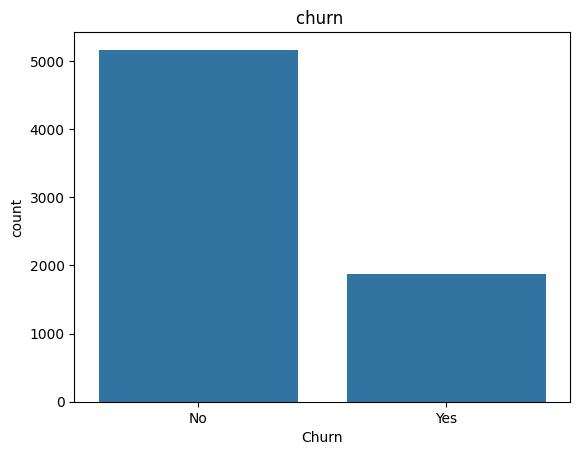

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Churn',data=df)
plt.title("churn ")
plt.show()

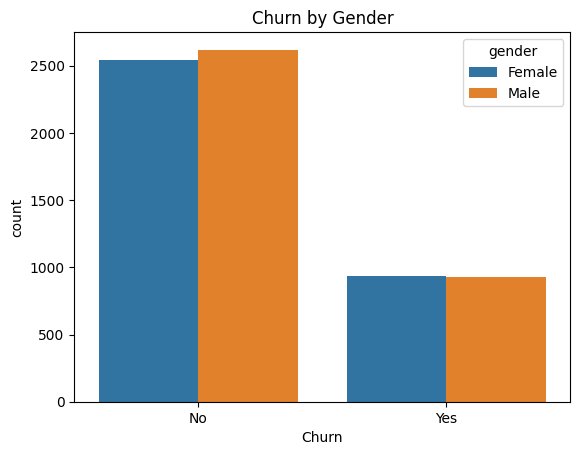

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='Churn',
    hue='gender',
    data=df
)

plt.title("Churn by Gender")

plt.show()

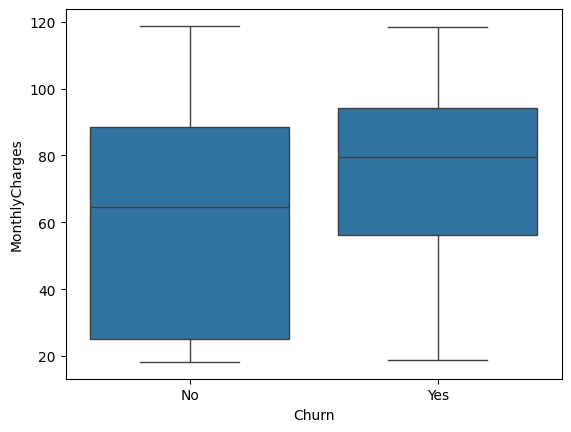

In [34]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

In [35]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if(df[col].dtype=='object'):
        df[col]=le.fit_transform(df[col])


In [36]:
x=df.drop('Churn',axis=1)
y=df['Churn']

In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,
                                               test_size=0.2,
                                               random_state=42,
                                               )

In [38]:
#standardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)



In [39]:
print(x_train.shape)

(5625, 19)


In [40]:
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import accuracy_score
le=LogisticRegression()
le.fit(x_train,y_train)
y_pred=le.predict(x_test)
print("accuracy_score",accuracy_score(y_test,y_pred))

accuracy_score 0.7853589196872779


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

print(accuracy_score(y_test, y_pred))

0.7882018479033405


🚀 TASK 2 — REGRESSION

Predict revenue.

In [42]:
y_reg = df["MonthlyCharges"]

X_reg = df.drop("MonthlyCharges", axis=1)

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lr_reg = LinearRegression()

lr_reg.fit(X_reg, y_reg)

pred = lr_reg.predict(X_reg)

print(mean_absolute_error(y_reg, pred))

10.859583603740134


🚀 TASK 3 — CLUSTERING

In [44]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(x)

🔍 KMeans

In [45]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_pca)

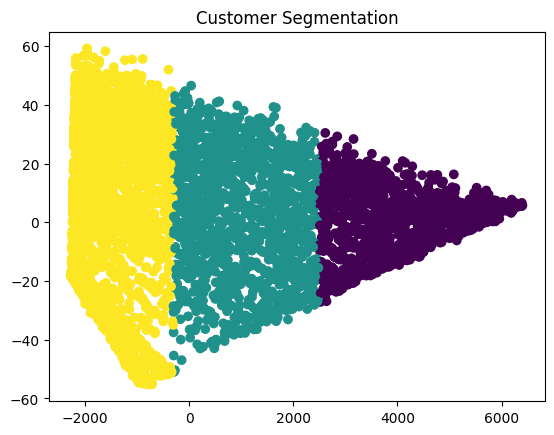

In [46]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.title("Customer Segmentation")

plt.show()

In [47]:
high_risk = df[
    (df['Contract'] == 0) &
    (df['MonthlyCharges'] > 80)
]

print(high_risk.head())

    gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
5        0              0        0           0       8             1   
6        1              0        0           1      22             1   
8        0              0        1           0      28             1   
13       1              0        0           0      49             1   
14       1              0        0           0      25             1   

    MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
5               2                1               0             0   
6               2                1               0             2   
8               2                1               0             0   
13              2                1               0             2   
14              0                1               2             0   

    DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
5                  2            0            2                2         0   
6   

In [48]:
import joblib

joblib.dump(rf, "churn_model.pkl")
joblib.dump(sc, "scaler.pkl")

['scaler.pkl']

In [49]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
